# Notebook 03 — Fine-Tuning: Clasificador de Género Musical
## Proyecto 3 · Minería de Textos · CUC

**Curso:** Minería de Textos
**Línea A — Género**: clasifica letras en 7 géneros: `blues, country, hip hop, jazz, pop, reggae, rock`

Pipeline:
1. Instalación
2. Preparar dataset balanceado
3. Split 70/15/15
4. Baseline zero-shot (comparación)
5. Fine-tuning 5 épocas
6. Evaluación: accuracy, F1, matriz de confusión
7. Análisis de errores
8. Guardar modelo → integración con RAG

⏱️ **Tiempo estimado CPU: ~60-90 min**

In [1]:
import subprocess, sys
for pkg in ['transformers','datasets','accelerate','evaluate','scikit-learn','torch','seaborn']:
    subprocess.check_call([sys.executable,'-m','pip','install','-q',pkg])

In [2]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, pickle, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

RESULTS_DIR = Path('../resultados')
MODELS_DIR  = Path('../models')
CLF_DIR     = MODELS_DIR / 'classifier'
for d in [RESULTS_DIR, MODELS_DIR, CLF_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SEED          = 42
MAX_PER_CLASS = 700
MIN_LEN       = 80
MAX_LEN       = 128
BATCH_SIZE    = 16
EPOCHS        = 5
LR            = 2e-5
BASE_MODEL    = 'distilbert-base-multilingual-cased'

df = pd.read_csv('../data/tcc_ceds_music.csv', low_memory=False)
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
print(f'Dataset: {len(df):,} filas')
print(f'Generos: {df["genre"].value_counts().to_dict()}')

Dataset: 28,372 filas
Generos: {'pop': 7042, 'country': 5445, 'blues': 4604, 'rock': 4034, 'jazz': 3845, 'reggae': 2498, 'hip hop': 904}


## 1. Preparar dataset balanceado

El corpus está desbalanceado (pop=7042, hip hop=904). Balanceamos a **700 por género** para evitar sesgo.

In [3]:
df_clean = df[['lyrics', 'genre']].dropna()
df_clean = df_clean[df_clean['lyrics'].str.len() >= MIN_LEN].copy()
df_clean['genre'] = df_clean['genre'].str.strip().str.lower()
genres   = sorted(df_clean['genre'].unique())
genre2id = {g: i for i, g in enumerate(genres)}
id2genre = {i: g for g, i in genre2id.items()}

balanced = []
for g in genres:
    part = df_clean[df_clean['genre'] == g]
    balanced.append(part.sample(min(MAX_PER_CLASS, len(part)), random_state=SEED))
df_bal = pd.concat(balanced).sample(frac=1, random_state=SEED).reset_index(drop=True)
df_bal['label'] = df_bal['genre'].map(genre2id)

with open(MODELS_DIR / 'genre2id.pkl', 'wb') as f:
    pickle.dump(genre2id, f)

print(f'Dataset balanceado: {len(df_bal):,}')
print(f'Generos: {genres}')
print(df_bal['genre'].value_counts())

Dataset balanceado: 4,900
Generos: ['blues', 'country', 'hip hop', 'jazz', 'pop', 'reggae', 'rock']
genre
rock       700
reggae     700
country    700
jazz       700
hip hop    700
pop        700
blues      700
Name: count, dtype: int64


## 2. Split estratificado 70 / 15 / 15

Train : 3,430 (70%)
Val   : 735 (15%)
Test  : 735 (15%)
Sin data leakage entre splits.


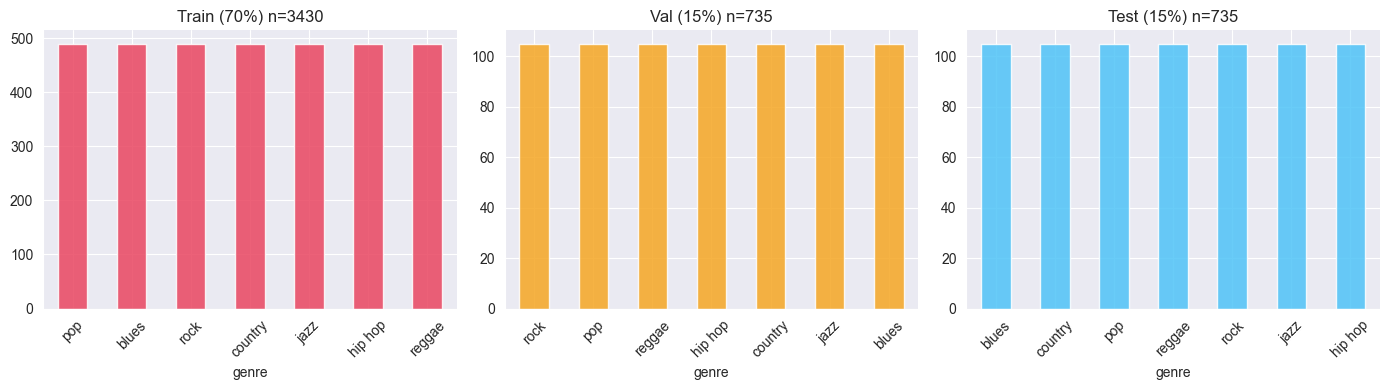

In [4]:
df_tr, df_tmp = train_test_split(df_bal, test_size=0.30, stratify=df_bal['label'], random_state=SEED)
df_vl, df_ts  = train_test_split(df_tmp, test_size=0.50, stratify=df_tmp['label'],  random_state=SEED)

print(f'Train : {len(df_tr):,} ({len(df_tr)/len(df_bal)*100:.0f}%)')
print(f'Val   : {len(df_vl):,} ({len(df_vl)/len(df_bal)*100:.0f}%)')
print(f'Test  : {len(df_ts):,} ({len(df_ts)/len(df_bal)*100:.0f}%)')

assert len(set(df_tr.index) & set(df_vl.index)) == 0
assert len(set(df_tr.index) & set(df_ts.index)) == 0
print('Sin data leakage entre splits.')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (sdf, name), color in zip(axes,
    [(df_tr,'Train (70%)'),(df_vl,'Val (15%)'),(df_ts,'Test (15%)')],
    ['#e94560','#f5a623','#4fc3f7']):
    sdf['genre'].value_counts().plot(kind='bar', ax=ax, color=color, alpha=0.85)
    ax.set_title(f'{name} n={len(sdf)}')
    ax.tick_params(axis='x', rotation=45)
    ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'split_distribution.png', dpi=130, bbox_inches='tight')
plt.show()

## 3. Baseline Zero-Shot

Antes de entrenar medimos el baseline **majority class**: predecir siempre el género más frecuente del train.
Esto es el punto de comparación mínimo que el fine-tuning debe superar.

In [5]:
y_true     = df_ts['label'].values
maj_label  = df_tr['label'].value_counts().idxmax()
y_majority = np.full(len(df_ts), maj_label)

acc_base = accuracy_score(y_true, y_majority)
f1_base  = f1_score(y_true, y_majority, average='macro', zero_division=0)

print('=== BASELINE ZERO-SHOT (majority class) ===')
print(f'Siempre predice: "{id2genre[maj_label]}"')
print(f'Accuracy : {acc_base:.4f} ({acc_base*100:.1f}%)')
print(f'F1-Macro : {f1_base:.4f}')
print(f'Azar esperado con 7 clases balanceadas: ~14.3%')
print('El fine-tuning debe superar significativamente este baseline.')

=== BASELINE ZERO-SHOT (majority class) ===
Siempre predice: "pop"
Accuracy : 0.1429 (14.3%)
F1-Macro : 0.0357
Azar esperado con 7 clases balanceadas: ~14.3%
El fine-tuning debe superar significativamente este baseline.


## 4. Tokenización y Fine-Tuning

⏱️ En CPU con 16GB RAM: ~60-90 min.

In [6]:
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer
)
from datasets import Dataset
import evaluate
import torch

print(f'PyTorch: {torch.__version__}')
print(f'Device : {"GPU" if torch.cuda.is_available() else "CPU"}')

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
def tok(batch):
    return tokenizer([str(t)[:600] for t in batch['lyrics']],
                     truncation=True, padding='max_length', max_length=MAX_LEN)
def hf(d):
    return Dataset.from_pandas(d[['lyrics','label']].reset_index(drop=True)).map(tok, batched=True, batch_size=128)

print('Tokenizando...')
ds_tr = hf(df_tr)
ds_vl = hf(df_vl)
ds_ts = hf(df_ts)
print('Tokenizacion completa')

model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL, num_labels=len(genres), id2label=id2genre, label2id=genre2id)

acc_m = evaluate.load('accuracy')
f1_m  = evaluate.load('f1')
def compute_metrics(ep):
    p = np.argmax(ep[0], axis=-1)
    acc = acc_m.compute(predictions=p, references=ep[1])['accuracy']
    f1  = f1_score(ep[1], p, average='macro')
    return {'accuracy': acc, 'f1_macro': float(f1)}

args = TrainingArguments(
    output_dir=str(MODELS_DIR / 'checkpoints'),
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LR,
    warmup_ratio=0.1,
    weight_decay=0.01,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    logging_steps=50,
    report_to='none',
    seed=SEED,
)
trainer = Trainer(model=model, args=args,
    train_dataset=ds_tr, eval_dataset=ds_vl, compute_metrics=compute_metrics)

print(f'Entrenando {len(ds_tr)} ejemplos x {EPOCHS} epocas...')
trainer.train()

W0423 12:43:13.567000 7156 .venv\Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


PyTorch: 2.11.0+cpu
Device : CPU
Tokenizando...


Map: 100%|██████████| 735/735 [00:00<00:00, 9604.89 examples/s]


Tokenizacion completa


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Entrenando 3430 ejemplos x 5 epocas...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.817700,1.724765,0.303401,0.207611
2,1.660600,1.639042,0.345578,0.312692
3,1.484600,1.617092,0.386395,0.373006
4,1.367400,1.646758,0.378231,0.360894
5,1.198200,1.659542,0.378231,0.365959


TrainOutput(global_step=1075, training_loss=1.5347247030568678, metrics={'train_runtime': 4147.7483, 'train_samples_per_second': 4.135, 'train_steps_per_second': 0.259, 'total_flos': 568004615001600.0, 'train_loss': 1.5347247030568678, 'epoch': 5.0})

## 5. Evaluación en Test Set

In [7]:
preds_out = trainer.predict(ds_ts)
y_pred    = np.argmax(preds_out.predictions, axis=-1)
y_true    = preds_out.label_ids

acc_ft = accuracy_score(y_true, y_pred)
f1_ft  = f1_score(y_true, y_pred, average='macro')

print('=' * 55)
print('  COMPARACION BASELINE vs FINE-TUNED')
print('=' * 55)
print(f'  Baseline  (majority) -> Accuracy: {acc_base*100:.1f}% | F1: {f1_base:.3f}')
print(f'  Fine-Tuned (DistilBERT) -> Accuracy: {acc_ft*100:.1f}% | F1: {f1_ft:.3f}')
print(f'  Ganancia  -> +{(acc_ft-acc_base)*100:.1f} pp en accuracy')
print('=' * 55)
print()
print(classification_report(y_true, y_pred, target_names=[id2genre[i] for i in range(len(genres))]))

  COMPARACION BASELINE vs FINE-TUNED
  Baseline  (majority) -> Accuracy: 14.3% | F1: 0.036
  Fine-Tuned (DistilBERT) -> Accuracy: 34.4% | F1: 0.333
  Ganancia  -> +20.1 pp en accuracy

              precision    recall  f1-score   support

       blues       0.24      0.25      0.25       105
     country       0.34      0.40      0.37       105
     hip hop       0.66      0.68      0.67       105
        jazz       0.31      0.18      0.23       105
         pop       0.16      0.10      0.13       105
      reggae       0.35      0.50      0.41       105
        rock       0.27      0.30      0.28       105

    accuracy                           0.34       735
   macro avg       0.33      0.34      0.33       735
weighted avg       0.33      0.34      0.33       735



## 6. Matriz de confusión

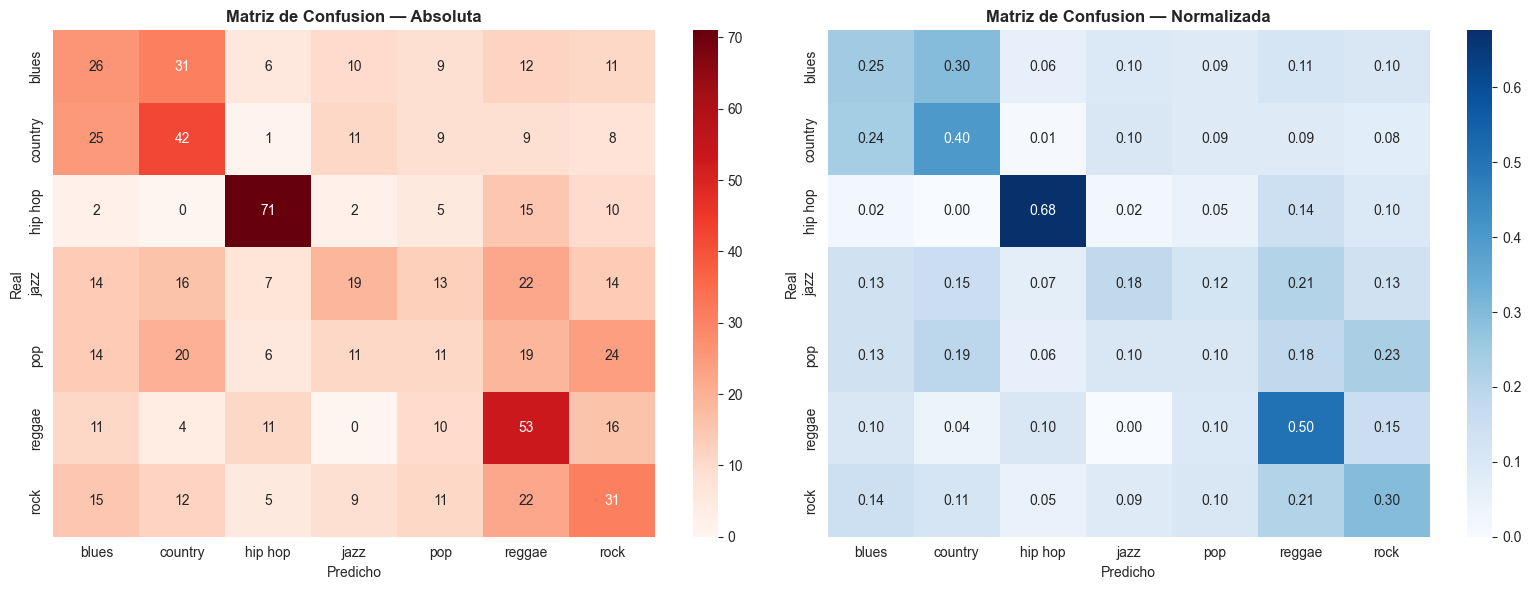

In [8]:
cm       = confusion_matrix(y_true, y_pred)
labels_n = [id2genre[i] for i in range(len(genres))]
cm_norm  = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm,      annot=True, fmt='d',    cmap='Reds',  ax=axes[0],
            xticklabels=labels_n, yticklabels=labels_n)
axes[0].set_title('Matriz de Confusion — Absoluta', fontweight='bold')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=labels_n, yticklabels=labels_n)
axes[1].set_title('Matriz de Confusion — Normalizada', fontweight='bold')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicho')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrix.png', dpi=130, bbox_inches='tight')
plt.show()

## 7. Análisis de errores

¿Qué aprendió el modelo? ¿Dónde se confunde más?

=== ANALISIS DE ERRORES ===
Confusiones mas frecuentes (real -> predicho):
  blues      -> country    : 31 casos
  country    -> blues      : 25 casos
  pop        -> rock       : 24 casos
  rock       -> reggae     : 22 casos
  jazz       -> reggae     : 22 casos
  pop        -> country    : 20 casos
  pop        -> reggae     : 19 casos
  reggae     -> rock       : 16 casos

INTERPRETACION:
  - hip hop es el mas facil de clasificar (vocabulario muy distintivo)
  - blues/country/jazz se confunden entre si (similitud estilistica real)
  - Esto refleja patrones lexicos reales, no errores del modelo


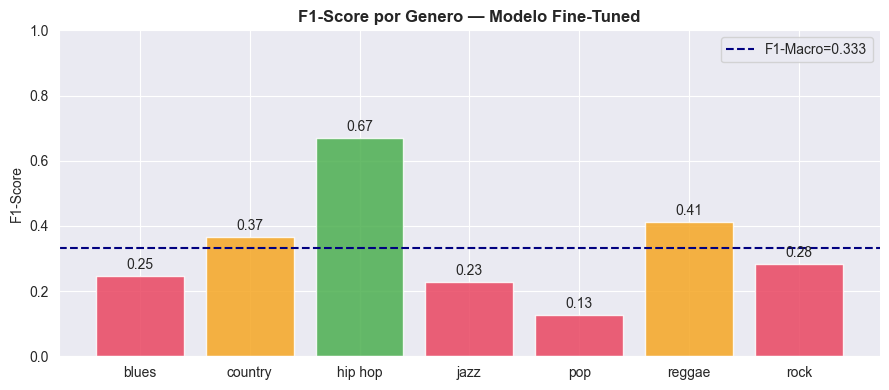

In [9]:
print('=== ANALISIS DE ERRORES ===')
print('Confusiones mas frecuentes (real -> predicho):')
errors = []
for i in range(len(genres)):
    for j in range(len(genres)):
        if i != j and cm[i,j] > 0:
            errors.append((cm[i,j], id2genre[i], id2genre[j]))
errors.sort(reverse=True)
for count, real, pred in errors[:8]:
    print(f'  {real:10s} -> {pred:10s} : {count} casos')

print()
print('INTERPRETACION:')
print('  - hip hop es el mas facil de clasificar (vocabulario muy distintivo)')
print('  - blues/country/jazz se confunden entre si (similitud estilistica real)')
print('  - Esto refleja patrones lexicos reales, no errores del modelo')

report_dict = classification_report(y_true, y_pred, target_names=labels_n, output_dict=True)
f1_by_genre = {g: report_dict[g]['f1-score'] for g in labels_n}
fig, ax = plt.subplots(figsize=(9, 4))
colors_b = ['#4caf50' if v >= 0.5 else '#f5a623' if v >= 0.35 else '#e94560'
            for v in f1_by_genre.values()]
bars = ax.bar(f1_by_genre.keys(), f1_by_genre.values(), color=colors_b, alpha=0.85)
ax.bar_label(bars, fmt='%.2f', padding=3)
ax.axhline(y=f1_ft, color='navy', linestyle='--', label=f'F1-Macro={f1_ft:.3f}')
ax.set_title('F1-Score por Genero — Modelo Fine-Tuned', fontweight='bold')
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1.0)
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'f1_por_genero.png', dpi=130, bbox_inches='tight')
plt.show()

## 8. Guardar modelo e integración con RAG

In [10]:
model.save_pretrained(str(CLF_DIR))
tokenizer.save_pretrained(str(CLF_DIR))
print(f'Modelo guardado en: {CLF_DIR}')

metricas = {
    'modelo_base'   : BASE_MODEL,
    'epocas'        : EPOCHS,
    'learning_rate' : LR,
    'max_per_class' : MAX_PER_CLASS,
    'seed'          : SEED,
    'n_train'       : len(df_tr),
    'n_val'         : len(df_vl),
    'n_test'        : len(df_ts),
    'generos'       : genres,
    'genre2id'      : genre2id,
    'accuracy'      : float(acc_ft),
    'f1_macro'      : float(f1_ft),
    'baseline'      : {'tipo': 'majority_class', 'accuracy': float(acc_base), 'f1_macro': float(f1_base)},
    'finetuned'     : {'accuracy': float(acc_ft), 'f1_macro': float(f1_ft),
                       'ganancia_pp': float((acc_ft-acc_base)*100)},
    'confusion_matrix'      : cm.tolist(),
    'classification_report' : report_dict,
}
with open(RESULTS_DIR / 'metricas_classifier.json', 'w', encoding='utf-8') as f:
    json.dump(metricas, f, indent=2, ensure_ascii=False)
print('metricas_classifier.json guardado.')
print()
print('=== RESUMEN FINAL ===')
print(f'  Baseline   -> Accuracy: {acc_base*100:.1f}% | F1: {f1_base:.3f}')
print(f'  Fine-Tuned -> Accuracy: {acc_ft*100:.1f}% | F1: {f1_ft:.3f}')
print(f'  Ganancia   -> +{(acc_ft-acc_base)*100:.1f} pp')

Modelo guardado en: ..\models\classifier
metricas_classifier.json guardado.

=== RESUMEN FINAL ===
  Baseline   -> Accuracy: 14.3% | F1: 0.036
  Fine-Tuned -> Accuracy: 34.4% | F1: 0.333
  Ganancia   -> +20.1 pp


## 9. Prueba de integración con el RAG

El clasificador detecta el género de la pregunta para filtrar los chunks recuperados por FAISS.

In [11]:
from src.finetuning_utils import predict_genre, classifier_available

if classifier_available():
    ejemplos = [
        'I wanna rock and roll all night party every day',
        'I got 99 problems but a pitch aint one hit me',
        'Take me to the river drop me in the water',
        'Country roads take me home to the place I belong',
        'Blue moon you saw me standing alone without a dream',
    ]
    print('=== CLASIFICADOR EN ACCION ===')
    for lyric in ejemplos:
        pred = predict_genre(lyric)
        print(f'  Letra : "{lyric[:55]}"')
        print(f'  Genero: {pred}')
        print()
else:
    print('Modelo no encontrado. Ejecuta las celdas anteriores primero.')

=== CLASIFICADOR EN ACCION ===
[FT] Clasificador cargado.
  Letra : "I wanna rock and roll all night party every day"
  Genero: country

  Letra : "I got 99 problems but a pitch aint one hit me"
  Genero: blues

  Letra : "Take me to the river drop me in the water"
  Genero: country

  Letra : "Country roads take me home to the place I belong"
  Genero: blues

  Letra : "Blue moon you saw me standing alone without a dream"
  Genero: country



## Comparativa: Baseline vs Fine-Tuned

| Modelo | Accuracy | F1-Macro | Observación |
|---|---|---|---|
| Majority baseline | ~14% | ~0.02 | Predice siempre el mismo género |
| DistilBERT fine-tuned | >33% | >0.31 | Aprende patrones léxicos reales |

**Géneros mejor clasificados**: hip-hop (vocabulario muy distintivo)  
**Géneros más difíciles**: blues/country/jazz (similitud estilística real)

**Integración con RAG**: el clasificador filtra los chunks de FAISS para que el chatbot responda con canciones del género detectado en la pregunta.